# This file is used to analyze the results of the experiments.

In [134]:
import pandas as pd
import numpy as np
import os
import sys
from sklearn.metrics import mean_squared_error
import json

In [163]:
DATASET_MAX_N_OBS = {
    'autompg': 400,
    'breastcancer': 200,
    'fertility': 100,  # Small dataset
    'forest': 500,
    'housing': 500,
    'pendulum': 500,
    'qsar_aquatic_toxicity': 500,
    'servo': 100,      # Small dataset
    'stock': 500,
    'yacht_hydrodynamics': 300 , # Medium dataset
    'ENB2012_data_energy_heating': 768,
    'ENB2012_data_energy_cooling': 768,
    'real_estate': 414,
    'winequality-red': 1599,
    'winequality-white': 4898,
    'airfoil_self_noise': 1503,
    'qsar_fish_toxicity': 908,
    'Combined_Cycle_Power_Plant': 9568,
}

def get_valid_n_obs_list(data_name, requested_n_obs_list):
    """
    Filter n_obs_list based on dataset's maximum available samples
    
    Args:
        data_name: Name of the dataset
        requested_n_obs_list: List of requested sample sizes
        
    Returns:
        Filtered list of valid sample sizes
    """
    max_n_obs = DATASET_MAX_N_OBS.get(data_name, 500)
    valid_list = [n for n in requested_n_obs_list if n <= max_n_obs]
    
    return valid_list

# List of datasets (same as in experiment)
data_names = [
    # 'autompg', # 'breastcancer', 
    'fertility', 
    'forest', # 'housing', 
    # 'pendulum',
    'qsar_aquatic_toxicity', 
    #'servo',  
    'stock', 
    'yacht_hydrodynamics',
    'real_estate',
    'winequality-red',
    'winequality-white',
    'qsar_fish_toxicity',
    'Combined_Cycle_Power_Plant'
]


In [164]:
# # Define base metrics directory (relative to analysis notebook location)
# metrics_dir = './metrics'

# # Create main metrics directory
# os.makedirs(metrics_dir, exist_ok=True)

# # Create subdirectory for each dataset
# for data_name in data_names:
#     data_metrics_dir = os.path.join(metrics_dir, data_name)
#     os.makedirs(data_metrics_dir, exist_ok=True)
#     print(f"Created metrics folder for: {data_name}")

# print(f"\nAll metrics folders created in: {metrics_dir}")
# print(f"Total datasets: {len(data_names)}")

# Get the Best SRF Model via Cross-Validation

In [165]:
def create_best_model_selection_df(data_name, n_obs_list_full=[50,100,200,300,400,500], 
                                     results_dir='../results', metrics_dir='./metrics'):
    """
    Create a DataFrame with best selected models for each replication
    
    Args:
        data_name: Dataset name (e.g., 'autompg')
        n_obs_list: List of sample sizes to analyze
        save: Whether to save results to CSV
        results_dir: Directory containing experiment results
        save_path: Path to save CSV (if None and save=True, will use default path)
    
    Returns:
        DataFrame with columns: data, n, r, best_SRF_norm, best_SRF_hyp
    """
    n_obs_list = get_valid_n_obs_list(data_name, n_obs_list_full)
    # List to store results
    results_list = []
    
    # Iterate through all sample sizes and replications
    for n_obs in n_obs_list:
        for r in range(100):  # Assuming 100 replications
            cv_file = f'{results_dir}/{data_name}/cv_results/{data_name}_n{n_obs}_r{r}.json'
            
            # Check if file exists
            if not os.path.exists(cv_file):
                continue
            
            try:
                # Load CV results
                with open(cv_file, 'r') as f:
                    cv_data = json.load(f)
                
                # Extract best modes
                best_norm = cv_data.get('normal', {}).get('best_mode', None)
                best_hyp = cv_data.get('hyperbolic_secant', {}).get('best_mode', None)
                
                # Create result dictionary
                result = {
                    'data': data_name,
                    'n': n_obs,
                    'r': r,
                    'best_SRF_norm': best_norm,
                    'best_SRF_hyp': best_hyp
                }
                
                results_list.append(result)
                
            except Exception as e:
                print(f"Error processing {data_name} n={n_obs} r={r}: {e}")
                continue
    
    # Create DataFrame
    results_df = pd.DataFrame(results_list)
    
    # Save if requested
    if metrics_dir:
        save_path = f'{metrics_dir}/{data_name}/{data_name}_best_model_selection.csv'
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        results_df.to_csv(save_path, index=False)
        print(f"Saved to: {save_path}")
    
    return results_df

In [166]:
for data in data_names:
    create_best_model_selection_df(data_name=data,metrics_dir= './metrics')

Saved to: ./metrics/fertility/fertility_best_model_selection.csv
Saved to: ./metrics/forest/forest_best_model_selection.csv
Saved to: ./metrics/qsar_aquatic_toxicity/qsar_aquatic_toxicity_best_model_selection.csv
Saved to: ./metrics/stock/stock_best_model_selection.csv
Saved to: ./metrics/yacht_hydrodynamics/yacht_hydrodynamics_best_model_selection.csv
Saved to: ./metrics/real_estate/real_estate_best_model_selection.csv
Saved to: ./metrics/winequality-red/winequality-red_best_model_selection.csv
Saved to: ./metrics/winequality-white/winequality-white_best_model_selection.csv
Saved to: ./metrics/qsar_fish_toxicity/qsar_fish_toxicity_best_model_selection.csv
Saved to: ./metrics/Combined_Cycle_Power_Plant/Combined_Cycle_Power_Plant_best_model_selection.csv


In [167]:
def combine_all_data_metrics(metric,data_list,metrics_path,save_path=None):
    metric_df = pd.DataFrame()
    for data_name in data_list:
        metric_df = pd.concat([metric_df,pd.read_csv(f'{metrics_path}/{data_name}/{data_name}_{metric}.csv')])

    if save_path is not None:
        metric_df.to_csv(f'{save_path}/{metric}_combined_all_data.csv',index=False)
    else:
        return metric_df

In [168]:
cv_best_model_selection_df = combine_all_data_metrics(metric='best_model_selection',
                                                        data_list=data_names,
                                                        metrics_path= './metrics')

# Calculate Mean Squared Error for each model and each dataset

In [169]:
def calculate_mse_metrics(data_name, n_obs_list_full = [50,100,200,300,400,500], 
                            results_dir='../results', metrics_dir='./metrics'):
    """
    Calculate MSE for all models across different sample sizes and replications
    
    Args:
        data_name: Dataset name (e.g., 'autompg')
        n_obs_list: List of sample sizes to analyze
        save: Whether to save results to CSV
        results_dir: Directory containing experiment results
        metrics_dir: Directory to save metrics (if None, won't save even if save=True)
    
    Returns:
        DataFrame with columns: data, n_obs, r, base_rf, rf10, rf100, srf_normal_*, srf_hypsec_*
    """
    n_obs_list = get_valid_n_obs_list(data_name, n_obs_list_full)
    # List to store results
    results_list = []
    
    # Define all model names (use original names for reading)
    model_names = ['base_rf', 'rf10', 'rf20', 'rf50', 'rf_100']
    
    # Add SRF models (2 kernels × 4 modes)
    for kernel in ['normal', 'hypsec']:
        for mode in ['global', 'per_dim', 'per_tree', 'per_tree_dim']:
            model_names.append(f'srf_{kernel}_{mode}')
    
    # Iterate through all sample sizes and replications
    for n_obs in n_obs_list:
        for r in range(100):  # 100 replications
            pred_file = f'{results_dir}/{data_name}/predictions/{data_name}_n{n_obs}_r{r}.csv'
            
            # Check if file exists
            if not os.path.exists(pred_file):
                continue
            
            try:
                # Load predictions
                pred_df = pd.read_csv(pred_file)
                y_test = pred_df['y_test'].values
                
                # Create result dictionary for this replication
                result = {
                    'data': data_name,
                    'n_obs': n_obs,
                    'r': r
                }
                
                # Calculate MSE for each model
                for model in model_names:
                    pred_col = f'{model}_pred'
                    
                    if pred_col in pred_df.columns:
                        y_pred = pred_df[pred_col].values
                        
                        # Check for NaN values
                        if np.any(np.isnan(y_pred)):
                            result[model] = np.nan
                        else:
                            result[model] = mean_squared_error(y_test, y_pred)
                    else:
                        result[model] = np.nan
                
                results_list.append(result)
                
            except Exception as e:
                print(f"Error processing {data_name} n={n_obs} r={r}: {e}")
                continue
    
    # Create DataFrame
    results_df = pd.DataFrame(results_list)
    
    # Rename rf_full to rf100
    model_names_display = [m if m != 'rf_100' else 'rf100' for m in model_names]
    results_df.rename(columns={'rf_100': 'rf100'}, inplace=True)
    
    # Reorder columns
    cols_order = ['data', 'n_obs', 'r'] + model_names_display
    results_df = results_df[cols_order]
    
    # Save if requested and metrics_dir is not None
    if metrics_dir is not None:
        save_path = f'{metrics_dir}/{data_name}/{data_name}_mse.csv'
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        results_df.to_csv(save_path, index=False)
        print(f"Saved metrics to: {save_path}")
    
    else:
        return results_df

In [170]:
for data in data_names:
    calculate_mse_metrics(data_name=data,metrics_dir= './metrics')

Saved metrics to: ./metrics/fertility/fertility_mse.csv
Saved metrics to: ./metrics/forest/forest_mse.csv
Saved metrics to: ./metrics/qsar_aquatic_toxicity/qsar_aquatic_toxicity_mse.csv
Saved metrics to: ./metrics/stock/stock_mse.csv
Saved metrics to: ./metrics/yacht_hydrodynamics/yacht_hydrodynamics_mse.csv
Saved metrics to: ./metrics/real_estate/real_estate_mse.csv
Saved metrics to: ./metrics/winequality-red/winequality-red_mse.csv
Saved metrics to: ./metrics/winequality-white/winequality-white_mse.csv
Saved metrics to: ./metrics/qsar_fish_toxicity/qsar_fish_toxicity_mse.csv
Saved metrics to: ./metrics/Combined_Cycle_Power_Plant/Combined_Cycle_Power_Plant_mse.csv


In [171]:
combined_mse = combine_all_data_metrics(metric='mse',data_list=data_names,metrics_path= './metrics')

In [172]:
combined_mse

,data,n_obs,r,base_rf,rf10,rf20,rf50,rf100,srf_normal_global,srf_normal_per_dim,srf_normal_per_tree,srf_normal_per_tree_dim,srf_hypsec_global,srf_hypsec_per_dim,srf_hypsec_per_tree,srf_hypsec_per_tree_dim
0,fertility,50,0,0.042050,0.044909,0.045380,0.046300,0.043865,0.037906,0.038305,0.038195,0.036698,0.037796,0.038361,0.038218,0.036774
1,fertility,50,1,0.040354,0.039270,0.035568,0.034324,0.035136,0.036886,0.039730,0.037839,0.034898,0.036858,0.039973,0.038715,0.035834
2,fertility,50,2,0.040279,0.041473,0.039620,0.041042,0.039670,0.040955,0.042024,0.040910,0.040070,0.040893,0.042142,0.041661,0.039901
3,fertility,50,3,0.037332,0.039350,0.042345,0.039342,0.039329,0.037678,0.040765,0.040368,0.036241,0.037869,0.040684,0.040569,0.037043
4,fertility,50,4,0.034472,0.038044,0.035255,0.034489,0.034218,0.035516,0.035561,0.035445,0.033234,0.035472,0.035538,0.035536,0.032951
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,Combined_Cycle_Power_Plant,500,95,20.726619,21.063966,20.376660,19.516723,19.339205,18.017967,18.190367,18.351168,18.282934,18.046246,18.254390,18.110081,18.261759
596,Combined_Cycle_Power_Plant,500,96,21.349108,21.337937,21.012749,20.129322,19.987684,17.871158,18.080545,18.025393,18.195703,17.908697,18.073451,17.961752,18.035373
597,Combined_Cycle_Power_Plant,500,97,20.627010,20.499778,19.931488,19.316219,19.063135,18.605252,18.637806,18.672389,18.617518,18.595323,18.600874,18.548112,18.584445
598,Combined_Cycle_Power_Plant,500,98,20.558776,20.167187,19.498746,19.099909,19.036338,18.500106,18.574570,18.538096,18.622296,18.497077,18.558536,18.460729,18.689058


# Get Percentage Improvement over Base RF

In [173]:
def calculate_percentage(df):
    pi_df = pd.DataFrame()
    pi_df['data'] = df['data']
    pi_df['n_obs'] = df['n_obs']
    pi_df['r'] = df['r']
    
    pi_df['rf10'] = round((df['base_rf'] - df['rf10'])/df['base_rf']*100,4)
    pi_df['rf20'] = round((df['base_rf'] - df['rf20'])/df['base_rf']*100,4)
    pi_df['rf50'] = round((df['base_rf'] - df['rf50'])/df['base_rf']*100,4)
    pi_df['rf100'] = round((df['base_rf'] - df['rf100'])/df['base_rf']*100,4)

    pi_df['srf_normal_global'] = round((df['base_rf'] - df['srf_normal_global'])/df['base_rf']*100,4)
    pi_df['srf_normal_per_dim'] = round((df['base_rf'] - df['srf_normal_per_dim'])/df['base_rf']*100,4)
    pi_df['srf_normal_per_tree'] = round((df['base_rf'] - df['srf_normal_per_tree'])/df['base_rf']*100,4)
    pi_df['srf_normal_per_tree_dim'] = round((df['base_rf'] - df['srf_normal_per_tree_dim'])/df['base_rf']*100,4)

    pi_df['srf_hypsec_global'] = round((df['base_rf'] - df['srf_hypsec_global'])/df['base_rf']*100,4)
    pi_df['srf_hypsec_per_dim'] = round((df['base_rf'] - df['srf_hypsec_per_dim'])/df['base_rf']*100,4)
    pi_df['srf_hypsec_per_tree'] = round((df['base_rf'] - df['srf_hypsec_per_tree'])/df['base_rf']*100,4)
    pi_df['srf_hypsec_per_tree_dim'] = round((df['base_rf'] - df['srf_hypsec_per_tree_dim'])/df['base_rf']*100,4)

    return pi_df

In [174]:
combined_mse

,data,n_obs,r,base_rf,rf10,rf20,rf50,rf100,srf_normal_global,srf_normal_per_dim,srf_normal_per_tree,srf_normal_per_tree_dim,srf_hypsec_global,srf_hypsec_per_dim,srf_hypsec_per_tree,srf_hypsec_per_tree_dim
0,fertility,50,0,0.042050,0.044909,0.045380,0.046300,0.043865,0.037906,0.038305,0.038195,0.036698,0.037796,0.038361,0.038218,0.036774
1,fertility,50,1,0.040354,0.039270,0.035568,0.034324,0.035136,0.036886,0.039730,0.037839,0.034898,0.036858,0.039973,0.038715,0.035834
2,fertility,50,2,0.040279,0.041473,0.039620,0.041042,0.039670,0.040955,0.042024,0.040910,0.040070,0.040893,0.042142,0.041661,0.039901
3,fertility,50,3,0.037332,0.039350,0.042345,0.039342,0.039329,0.037678,0.040765,0.040368,0.036241,0.037869,0.040684,0.040569,0.037043
4,fertility,50,4,0.034472,0.038044,0.035255,0.034489,0.034218,0.035516,0.035561,0.035445,0.033234,0.035472,0.035538,0.035536,0.032951
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,Combined_Cycle_Power_Plant,500,95,20.726619,21.063966,20.376660,19.516723,19.339205,18.017967,18.190367,18.351168,18.282934,18.046246,18.254390,18.110081,18.261759
596,Combined_Cycle_Power_Plant,500,96,21.349108,21.337937,21.012749,20.129322,19.987684,17.871158,18.080545,18.025393,18.195703,17.908697,18.073451,17.961752,18.035373
597,Combined_Cycle_Power_Plant,500,97,20.627010,20.499778,19.931488,19.316219,19.063135,18.605252,18.637806,18.672389,18.617518,18.595323,18.600874,18.548112,18.584445
598,Combined_Cycle_Power_Plant,500,98,20.558776,20.167187,19.498746,19.099909,19.036338,18.500106,18.574570,18.538096,18.622296,18.497077,18.558536,18.460729,18.689058


In [175]:
all_models_pi = calculate_percentage(combined_mse)

In [176]:
combined_mse

,data,n_obs,r,base_rf,rf10,rf20,rf50,rf100,srf_normal_global,srf_normal_per_dim,srf_normal_per_tree,srf_normal_per_tree_dim,srf_hypsec_global,srf_hypsec_per_dim,srf_hypsec_per_tree,srf_hypsec_per_tree_dim
0,fertility,50,0,0.042050,0.044909,0.045380,0.046300,0.043865,0.037906,0.038305,0.038195,0.036698,0.037796,0.038361,0.038218,0.036774
1,fertility,50,1,0.040354,0.039270,0.035568,0.034324,0.035136,0.036886,0.039730,0.037839,0.034898,0.036858,0.039973,0.038715,0.035834
2,fertility,50,2,0.040279,0.041473,0.039620,0.041042,0.039670,0.040955,0.042024,0.040910,0.040070,0.040893,0.042142,0.041661,0.039901
3,fertility,50,3,0.037332,0.039350,0.042345,0.039342,0.039329,0.037678,0.040765,0.040368,0.036241,0.037869,0.040684,0.040569,0.037043
4,fertility,50,4,0.034472,0.038044,0.035255,0.034489,0.034218,0.035516,0.035561,0.035445,0.033234,0.035472,0.035538,0.035536,0.032951
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,Combined_Cycle_Power_Plant,500,95,20.726619,21.063966,20.376660,19.516723,19.339205,18.017967,18.190367,18.351168,18.282934,18.046246,18.254390,18.110081,18.261759
596,Combined_Cycle_Power_Plant,500,96,21.349108,21.337937,21.012749,20.129322,19.987684,17.871158,18.080545,18.025393,18.195703,17.908697,18.073451,17.961752,18.035373
597,Combined_Cycle_Power_Plant,500,97,20.627010,20.499778,19.931488,19.316219,19.063135,18.605252,18.637806,18.672389,18.617518,18.595323,18.600874,18.548112,18.584445
598,Combined_Cycle_Power_Plant,500,98,20.558776,20.167187,19.498746,19.099909,19.036338,18.500106,18.574570,18.538096,18.622296,18.497077,18.558536,18.460729,18.689058


# Get the Best Model via Cross-Validation Metrics

In [177]:
cv_best_model_selection_df

,data,n,r,best_SRF_norm,best_SRF_hyp
0,fertility,50,0,per_tree_dim,per_tree_dim
1,fertility,50,1,global,per_tree_dim
2,fertility,50,2,per_tree_dim,per_tree_dim
3,fertility,50,3,per_tree_dim,per_tree_dim
4,fertility,50,4,per_tree_dim,per_tree_dim
...,...,...,...,...,...
595,Combined_Cycle_Power_Plant,500,95,per_tree,per_tree_dim
596,Combined_Cycle_Power_Plant,500,96,per_tree_dim,per_tree_dim
597,Combined_Cycle_Power_Plant,500,97,per_tree_dim,per_tree_dim
598,Combined_Cycle_Power_Plant,500,98,per_tree_dim,per_tree_dim


In [ ]:
def create_selected_models_mse_df(combined_mse_df, cv_best_model_df):
    """
    Create a DataFrame with MSE values for selected best models
    
    Args:
        combined_mse_df: DataFrame with all models' MSE (from calculate_mse_metrics)
        cv_best_model_df: DataFrame with best model selection (from create_best_model_selection_df)
    
    Returns:
        DataFrame with columns: data, n, r, base_rf, rf10, rf100, SRF(norm), SRF(hyp)
    """  
    # Merge the two dataframes on data, n_obs/n, and r
    # First, standardize column names
    mse_df = combined_mse_df.copy()
    best_df = cv_best_model_df.copy()
    
    # Rename 'n' to 'n_obs' in best_df if needed for merging
    if 'n' in best_df.columns:
        best_df = best_df.rename(columns={'n': 'n_obs'})
    
    # Merge on data, n_obs, r
    merged_df = pd.merge(mse_df, best_df, on=['data', 'n_obs', 'r'], how='inner')
    
    # Create result list
    results_list = []
    
    for idx, row in merged_df.iterrows():
        # Get basic info
        data_name = row['data']
        n_obs = row['n_obs']
        r = row['r']
        
        # Get baseline models MSE
        base_rf_mse = row['base_rf']
        rf10_mse = row['rf10']
        rf20_mse = row['rf20']
        rf50_mse = row['rf50']
        rf100_mse = row['rf100']
        
        # Get best model modes
        best_norm_mode = row['best_SRF_norm']
        best_hyp_mode = row['best_SRF_hyp']
        
        # Get corresponding SRF MSE values
        srf_norm_col = f'srf_normal_{best_norm_mode}'
        srf_hyp_col = f'srf_hypsec_{best_hyp_mode}'
        
        srf_norm_mse = row[srf_norm_col] if srf_norm_col in row else np.nan
        srf_hyp_mse = row[srf_hyp_col] if srf_hyp_col in row else np.nan
        
        # Create result dictionary
        result = {
            'data': data_name,
            'n': n_obs,
            'r': r,
            'base_rf': base_rf_mse,
            'rf10': rf10_mse,
            'rf20': rf20_mse,
            'rf50': rf50_mse,
            'rf100': rf100_mse,
            'SRF(norm)': srf_norm_mse,
            'SRF(hyp)': srf_hyp_mse
        }
        
        results_list.append(result)
    
    # Create final DataFrame
    result_df = pd.DataFrame(results_list)
    
    return result_df

In [179]:
best_model_mse = create_selected_models_mse_df(combined_mse_df = combined_mse, 
                                            cv_best_model_df = cv_best_model_selection_df)

In [235]:
best_model_mse

,data,n,r,base_rf,rf10,rf20,rf50,rf100,SRF(norm),SRF(hyp)
0,fertility,50,0,0.042050,0.044909,0.045380,0.046300,0.043865,0.036698,0.036774
1,fertility,50,1,0.040354,0.039270,0.035568,0.034324,0.035136,0.036886,0.035834
2,fertility,50,2,0.040279,0.041473,0.039620,0.041042,0.039670,0.040070,0.039901
3,fertility,50,3,0.037332,0.039350,0.042345,0.039342,0.039329,0.036241,0.037043
4,fertility,50,4,0.034472,0.038044,0.035255,0.034489,0.034218,0.033234,0.032951
...,...,...,...,...,...,...,...,...,...,...
5295,Combined_Cycle_Power_Plant,500,95,20.726619,21.063966,20.376660,19.516723,19.339205,18.351168,18.261759
5296,Combined_Cycle_Power_Plant,500,96,21.349108,21.337937,21.012749,20.129322,19.987684,18.195703,18.035373
5297,Combined_Cycle_Power_Plant,500,97,20.627010,20.499778,19.931488,19.316219,19.063135,18.617518,18.584445
5298,Combined_Cycle_Power_Plant,500,98,20.558776,20.167187,19.498746,19.099909,19.036338,18.622296,18.689058


In [262]:
best_model_pi = pd.DataFrame()
best_model_pi['data'] = best_model_mse['data']
best_model_pi['n'] = best_model_mse['n']
best_model_pi['r'] = best_model_mse['r']
best_model_pi['rf10'] = round((best_model_mse['base_rf'] - best_model_mse['rf10'])/best_model_mse['base_rf']*100,4)
best_model_pi['rf20'] = round((best_model_mse['base_rf'] - best_model_mse['rf20'])/best_model_mse['base_rf']*100,4)
best_model_pi['rf50'] = round((best_model_mse['base_rf'] - best_model_mse['rf50'])/best_model_mse['base_rf']*100,4)
best_model_pi['rf100'] = round((best_model_mse['base_rf'] - best_model_mse['rf100'])/best_model_mse['base_rf']*100,4)
best_model_pi['SRF(norm)'] = round((best_model_mse['base_rf'] - best_model_mse['SRF(norm)'])/best_model_mse['base_rf']*100,4)
best_model_pi['SRF(hyp)'] = round((best_model_mse['base_rf'] - best_model_mse['SRF(hyp)'])/best_model_mse['base_rf']*100,4)

In [263]:
def add_data_info(data_names):
    data_info = pd.DataFrame()
    p_list = []
    n_list = []
    for data_name in data_names:
        data = pd.read_csv(f'../../data/{data_name}.csv')
        p_list.append(data.shape[1]-1)
        n_list.append(data.shape[0])
    data_info['data'] = data_names
    data_info['P'] = p_list
    data_info['N'] = n_list
    return data_info

In [264]:
data_info = add_data_info(data_names)

In [274]:
data_info

,data,P,N
0,fertility,9,100
1,forest,12,517
2,qsar_aquatic_toxicity,8,537
3,stock,11,536
4,yacht_hydrodynamics,6,308
5,real_estate,6,414
6,winequality-red,11,1599
7,winequality-white,11,4898
8,qsar_fish_toxicity,6,908
9,Combined_Cycle_Power_Plant,4,9568


In [265]:
best_model_pi

,data,n,r,rf10,rf20,rf50,rf100,SRF(norm),SRF(hyp)
0,fertility,50,0,-6.7998,-7.9205,-10.1073,-4.3168,12.7273,12.5468
1,fertility,50,1,2.6858,11.8613,14.9435,12.9300,8.5939,11.2022
2,fertility,50,2,-2.9650,1.6365,-1.8944,1.5112,0.5200,0.9391
3,fertility,50,3,-5.4073,-13.4285,-5.3860,-5.3510,2.9201,0.7728
4,fertility,50,4,-10.3630,-2.2720,-0.0497,0.7377,3.5897,4.4131
...,...,...,...,...,...,...,...,...,...
5295,Combined_Cycle_Power_Plant,500,95,-1.6276,1.6885,5.8374,6.6939,11.4609,11.8922
5296,Combined_Cycle_Power_Plant,500,96,0.0523,1.5755,5.7135,6.3770,14.7707,15.5217
5297,Combined_Cycle_Power_Plant,500,97,0.6168,3.3719,6.3547,7.5817,9.7420,9.9024
5298,Combined_Cycle_Power_Plant,500,98,1.9047,5.1561,7.0961,7.4053,9.4192,9.0945


In [266]:
# combine data_info with best_model_pi
best_model_pi = pd.merge(best_model_pi, data_info, on='data', how='left')
# rename n to n_obs
best_model_pi = best_model_pi.rename(columns={'n': 'n_obs','data':'Data'})
# order the columns
best_model_pi = best_model_pi[['Data','N','P','n_obs','r','rf10','rf20','rf50','rf100','SRF(norm)','SRF(hyp)']]

In [267]:
best_model_pi

,Data,N,P,n_obs,r,rf10,rf20,rf50,rf100,SRF(norm),SRF(hyp)
0,fertility,100,9,50,0,-6.7998,-7.9205,-10.1073,-4.3168,12.7273,12.5468
1,fertility,100,9,50,1,2.6858,11.8613,14.9435,12.9300,8.5939,11.2022
2,fertility,100,9,50,2,-2.9650,1.6365,-1.8944,1.5112,0.5200,0.9391
3,fertility,100,9,50,3,-5.4073,-13.4285,-5.3860,-5.3510,2.9201,0.7728
4,fertility,100,9,50,4,-10.3630,-2.2720,-0.0497,0.7377,3.5897,4.4131
...,...,...,...,...,...,...,...,...,...,...,...
5295,Combined_Cycle_Power_Plant,9568,4,500,95,-1.6276,1.6885,5.8374,6.6939,11.4609,11.8922
5296,Combined_Cycle_Power_Plant,9568,4,500,96,0.0523,1.5755,5.7135,6.3770,14.7707,15.5217
5297,Combined_Cycle_Power_Plant,9568,4,500,97,0.6168,3.3719,6.3547,7.5817,9.7420,9.9024
5298,Combined_Cycle_Power_Plant,9568,4,500,98,1.9047,5.1561,7.0961,7.4053,9.4192,9.0945


In [379]:
PIMSE_mean_data=best_model_pi.groupby(['Data','n_obs','N','P']).mean().drop(columns=['r']).reset_index()

In [381]:
PIMSE_mean_data.to_csv('PIMSE_mean_data.csv',index=False)

In [295]:
PIMSE_mean = best_model_pi.groupby(['Data','N','P']).mean().drop(columns=['r','n_obs']).reset_index()
PIMSE_std = best_model_pi.groupby(['Data','N','P']).std().drop(columns=['r','n_obs']).reset_index()
best_model_pi['cases'] = 1
cased_by_n_obs = best_model_pi.groupby(['Data']).sum().reset_index()
PIMSE_std['cases'] = cased_by_n_obs['cases']


In [297]:
PIMSE_std

,Data,N,P,rf10,rf20,rf50,rf100,SRF(norm),SRF(hyp),cases
0,Combined_Cycle_Power_Plant,9568,4,7.845028,6.921646,6.669572,6.501295,4.454423,4.359292,600
1,fertility,100,9,14.854777,13.961955,13.010236,12.554857,13.491159,13.542040,200
2,forest,517,12,7.575986,6.964496,6.444539,6.112992,5.553567,5.564677,600
3,qsar_aquatic_toxicity,537,8,8.720555,7.550497,7.251476,6.934707,5.705265,5.720673,600
4,qsar_fish_toxicity,908,6,6.515340,5.907117,5.537872,5.386228,5.519452,5.560794,600
5,real_estate,414,6,17.411632,15.277044,12.559371,12.966222,10.424672,10.694885,500
6,stock,536,11,9.988777,9.128861,8.176568,7.967473,8.575852,8.650871,600
7,winequality-red,1599,11,6.053888,5.113076,5.105366,5.182481,5.142591,5.150976,600
8,winequality-white,4898,11,5.502218,4.691791,4.403612,4.428345,5.017683,5.117946,600
9,yacht_hydrodynamics,308,6,52.026065,36.364890,25.758874,24.151975,20.469113,20.569427,400


In [289]:
PIMSE_mean

,Data,N,P,rf10,rf20,rf50,rf100,SRF(norm),SRF(hyp)
0,Combined_Cycle_Power_Plant,9568,4,2.369296,6.783136,9.251076,9.990132,12.682351,13.378657
1,fertility,100,9,-3.200528,-1.914922,-0.154162,0.691036,9.787076,9.892057
2,forest,517,12,-0.533817,2.542883,4.462138,5.186017,16.529607,16.424140
3,qsar_aquatic_toxicity,537,8,1.714275,6.072651,8.096803,8.776720,6.425268,6.321824
4,qsar_fish_toxicity,908,6,1.257037,4.773420,6.927701,7.567488,7.392085,7.206659
5,real_estate,414,6,0.544440,4.553913,7.311933,7.931318,0.945670,1.066104
6,stock,536,11,3.875635,12.174343,14.896424,15.714787,16.133181,16.031424
7,winequality-red,1599,11,0.737549,4.545769,6.578623,7.311013,5.863717,5.676036
8,winequality-white,4898,11,0.699309,4.716045,7.064115,7.847116,5.085392,4.863113
9,yacht_hydrodynamics,308,6,5.242822,26.086825,39.982941,43.025708,25.710043,25.153400


In [ ]:
mean_mse_95CI = pd.DataFrame()
mean_mse_95CI['Data'] = PIMSE_mean['Data']
mean_mse_95CI['N'] = PIMSE_mean['N']
mean_mse_95CI['P'] = PIMSE_mean['P']

mean_mse_95CI['rf10'] = round(PIMSE_mean['rf10'],2).astype(str) + ' (' + round(PIMSE_std['rf10']/np.sqrt(PIMSE_std['cases']),2).astype(str) + ')'
mean_mse_95CI['rf20'] = round(PIMSE_mean['rf20'],2).astype(str) + ' (' + round(PIMSE_std['rf20']/np.sqrt(PIMSE_std['cases']),2).astype(str) + ')'
mean_mse_95CI['rf50'] = round(PIMSE_mean['rf50'],2).astype(str) + ' (' + round(PIMSE_std['rf50']/np.sqrt(PIMSE_std['cases']),2).astype(str) + ')'
mean_mse_95CI['rf100'] = round(PIMSE_mean['rf100'],2).astype(str) + ' (' + round(PIMSE_std['rf100']/np.sqrt(PIMSE_std['cases']),2).astype(str) + ')'
mean_mse_95CI['SRF(norm)'] = round(PIMSE_mean['SRF(norm)'],2).astype(str) + ' (' + round(PIMSE_std['SRF(norm)']/np.sqrt(PIMSE_std['cases']),2).astype(str) + ')'
mean_mse_95CI['SRF(hyp)'] = round(PIMSE_mean['SRF(hyp)'],2).astype(str) + ' (' + round(PIMSE_std['SRF(hyp)']/np.sqrt(PIMSE_std['cases']),2).astype(str) + ')'

In [299]:
mean_mse_95CI

,Data,N,P,rf10,rf20,rf50,rf100,SRF(norm),SRF(hyp)
0,Combined_Cycle_Power_Plant,9568,4,2.37 (0.32),6.78 (0.28),9.25 (0.27),9.99 (0.27),12.68 (0.18),13.38 (0.18)
1,fertility,100,9,-3.2 (1.05),-1.91 (0.99),-0.15 (0.92),0.69 (0.89),9.79 (0.95),9.89 (0.96)
2,forest,517,12,-0.53 (0.31),2.54 (0.28),4.46 (0.26),5.19 (0.25),16.53 (0.23),16.42 (0.23)
3,qsar_aquatic_toxicity,537,8,1.71 (0.36),6.07 (0.31),8.1 (0.3),8.78 (0.28),6.43 (0.23),6.32 (0.23)
4,qsar_fish_toxicity,908,6,1.26 (0.27),4.77 (0.24),6.93 (0.23),7.57 (0.22),7.39 (0.23),7.21 (0.23)
5,real_estate,414,6,0.54 (0.78),4.55 (0.68),7.31 (0.56),7.93 (0.58),0.95 (0.47),1.07 (0.48)
6,stock,536,11,3.88 (0.41),12.17 (0.37),14.9 (0.33),15.71 (0.33),16.13 (0.35),16.03 (0.35)
7,winequality-red,1599,11,0.74 (0.25),4.55 (0.21),6.58 (0.21),7.31 (0.21),5.86 (0.21),5.68 (0.21)
8,winequality-white,4898,11,0.7 (0.22),4.72 (0.19),7.06 (0.18),7.85 (0.18),5.09 (0.2),4.86 (0.21)
9,yacht_hydrodynamics,308,6,5.24 (2.6),26.09 (1.82),39.98 (1.29),43.03 (1.21),25.71 (1.02),25.15 (1.03)


In [301]:
# order the rows by P
mean_best_model_pi = mean_mse_95CI.sort_values(by='P',ascending=True)
# rename model names
mean_best_model_pi = mean_best_model_pi.rename(columns={'rf10':'RF(10)',
                                                        'rf20':'RF(20)',
                                                        'rf50':'RF(50)',
                                                        'rf100':'RF(100)',
                                                        'SRF(norm)':'SRF(norm)',
                                                        'SRF(hyp)':'SRF(hyp)'})

In [302]:
mean_best_model_pi

,Data,N,P,RF(10),RF(20),RF(50),RF(100),SRF(norm),SRF(hyp)
0,Combined_Cycle_Power_Plant,9568,4,2.37 (0.32),6.78 (0.28),9.25 (0.27),9.99 (0.27),12.68 (0.18),13.38 (0.18)
4,qsar_fish_toxicity,908,6,1.26 (0.27),4.77 (0.24),6.93 (0.23),7.57 (0.22),7.39 (0.23),7.21 (0.23)
5,real_estate,414,6,0.54 (0.78),4.55 (0.68),7.31 (0.56),7.93 (0.58),0.95 (0.47),1.07 (0.48)
9,yacht_hydrodynamics,308,6,5.24 (2.6),26.09 (1.82),39.98 (1.29),43.03 (1.21),25.71 (1.02),25.15 (1.03)
3,qsar_aquatic_toxicity,537,8,1.71 (0.36),6.07 (0.31),8.1 (0.3),8.78 (0.28),6.43 (0.23),6.32 (0.23)
1,fertility,100,9,-3.2 (1.05),-1.91 (0.99),-0.15 (0.92),0.69 (0.89),9.79 (0.95),9.89 (0.96)
6,stock,536,11,3.88 (0.41),12.17 (0.37),14.9 (0.33),15.71 (0.33),16.13 (0.35),16.03 (0.35)
7,winequality-red,1599,11,0.74 (0.25),4.55 (0.21),6.58 (0.21),7.31 (0.21),5.86 (0.21),5.68 (0.21)
8,winequality-white,4898,11,0.7 (0.22),4.72 (0.19),7.06 (0.18),7.85 (0.18),5.09 (0.2),4.86 (0.21)
2,forest,517,12,-0.53 (0.31),2.54 (0.28),4.46 (0.26),5.19 (0.25),16.53 (0.23),16.42 (0.23)


In [ ]:
#mean_best_model_pi.to_csv('mean_cv_selected_model_pi_se.csv',index=False)

In [308]:
best_model_pi

,Data,N,P,n_obs,r,rf10,rf20,rf50,rf100,SRF(norm),SRF(hyp),cases
0,fertility,100,9,50,0,-6.7998,-7.9205,-10.1073,-4.3168,12.7273,12.5468,1
1,fertility,100,9,50,1,2.6858,11.8613,14.9435,12.9300,8.5939,11.2022,1
2,fertility,100,9,50,2,-2.9650,1.6365,-1.8944,1.5112,0.5200,0.9391,1
3,fertility,100,9,50,3,-5.4073,-13.4285,-5.3860,-5.3510,2.9201,0.7728,1
4,fertility,100,9,50,4,-10.3630,-2.2720,-0.0497,0.7377,3.5897,4.4131,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5295,Combined_Cycle_Power_Plant,9568,4,500,95,-1.6276,1.6885,5.8374,6.6939,11.4609,11.8922,1
5296,Combined_Cycle_Power_Plant,9568,4,500,96,0.0523,1.5755,5.7135,6.3770,14.7707,15.5217,1
5297,Combined_Cycle_Power_Plant,9568,4,500,97,0.6168,3.3719,6.3547,7.5817,9.7420,9.9024,1
5298,Combined_Cycle_Power_Plant,9568,4,500,98,1.9047,5.1561,7.0961,7.4053,9.4192,9.0945,1


In [304]:
from matplotlib import pyplot as plt

In [348]:
from matplotlib.ticker import MultipleLocator

def label_mapping_func(com_name):
    pir_name = r'$PI_{MSE}$'
    return f'{pir_name}({com_name})'


def plot_metric_percentage_improve(result_df,
                                   data_name_mapping,
                                   ncol=5,
                                plot_type='line',
                                figure_size = (20,13),
                                show_legend=False,
                                save_path=None):
    
    #data_list = metric_df['data'].unique().tolist()
    rows = len(data_name_mapping)//ncol
    models = {'rf10':'RF(10)',
              'rf20':'RF(20)',
              'rf50':'RF(50)',
              'rf100':'RF(100)',
              'SRF(norm)':'SRF(Norm)',
              'SRF(hyp)':'SRF(Hypsec)'}
    
    srf_models = ['SRF(norm)','SRF(hyp)']
    cmap = plt.get_cmap("tab10")

    color_mapping = {
            'rf10':cmap(0), 
            'rf20':cmap(1),
            'rf50':cmap(2),
            'rf100':cmap(3),
            'SRF(norm)':cmap(4),
            'SRF(hyp)':cmap(5)
        }

    if len(data_name_mapping)%ncol != 0:
        rows += 1
    fig,axes = plt.subplots(rows,ncol,figsize=figure_size,sharex=False,sharey=False,)
    for i,data in enumerate(data_name_mapping):
        data_name = data_name_mapping[data]
        data_df = result_df[result_df['Data']==data]
        q_list = data_df['n_obs'].unique().tolist()

        q_list_strings = list(map(str, q_list)) 
        if q_list[1] == 20 and len(q_list) > 4:
            q_list_strings[1] = ''
        n_obs = data_df['N'].unique()[0]
        dim = data_df['P'].unique()[0]
        # print("q_list:", q_list)
        for model in models:
            model_name = models[model]
            mean_list = data_df[[model,'n_obs','r']].groupby('n_obs').mean()[model].values.tolist()
            std_list = data_df[[model,'n_obs','r']].groupby('n_obs').std()[model].values.tolist()
            # get 95% confidence interval
            std_list = [1.96*std/np.sqrt(100) for std in std_list]
            #mean_list = [mean*100 for mean in mean_list]
            if plot_type == 'line':
                axes[i//ncol,i%ncol].plot(q_list,mean_list,label=label_mapping_func(model_name),marker='.',color = color_mapping[model])
            elif plot_type == 'errorbar':
                eb = axes[i//ncol,i%ncol].errorbar(q_list,mean_list,yerr=std_list,
                                              label=label_mapping_func(model_name),
                                              color = color_mapping[model],
                                              linewidth=3,
                                              capsize=5,
                                              linestyle='-' if model in srf_models else '--')
                eb[-1][0].set_linestyle((0, (1, 1)))
            
        # axes[i//ncol,i%ncol].set_title(r"{} ($\mathit{{n={}}}$, $\mathit{{p={}}}$)".format(data.capitalize(), n_obs, dim), fontsize = 20)
        axes[i//ncol,i%ncol].set_title(data_name + "\n" + "($\mathit{{n="+str(n_obs)+"}}$, $\mathit{{p="+str(dim)+"}}$)", fontsize = 26)
        #axes[i//ncol,i%ncol].set_xlabel('Training Size',fontsize = 15)
        # set xticks fontsize
        axes[i//ncol,i%ncol].tick_params(axis='x', labelsize=22)
        axes[i//ncol,i%ncol].tick_params(axis='y', labelsize=22)

        ##########################
        ##### Added by Felix #####
        axes[i//ncol,i%ncol].set_xticks(q_list)
        axes[i//ncol,i%ncol].set_xticklabels(q_list_strings)
        axes[i//ncol,i%ncol].xaxis.set_tick_params(rotation=60) 
        ##########################
        # if i//ncol ==0:
        #     axes[i//ncol,i%ncol].set_yscale('symlog',linthresh=0.15)
        # else:  
        #     axes[i//ncol,i%ncol].set_yscale('symlog',linthresh=0.15)
        axes[i//ncol,i%ncol].grid()
        
        # add a horizontal line at 0
        axes[i//ncol,i%ncol].axhline(0, color='grey', linestyle='--')
    #axes[i//ncol,i%ncol].set_yscale('symlog',linthresh=0.2)


    # axes[0,0].set_yscale('symlog', linthresh=0.01)
    # axes[1,0].set_yscale('symlog', linthresh=0.01)

        
    if show_legend:
     
        handles, labels = axes[0,0].get_legend_handles_labels()
    
        fig.legend(handles, labels, loc='upper center', fontsize=22, ncol=6,
              bbox_to_anchor=(0.5, 1.09))  # 0.5表示水平居中
        ##########################
    #all suplots use one y label
    fig.text(-0.01,0.5,'MSE Percentage Improvement',va = 'center',rotation='vertical',fontsize = 30)
    fig.text(0.5,-0.02,'Training Size',ha = 'center',fontsize = 28)
    plt.subplots_adjust(wspace=0.05)
    plt.tight_layout()
    # save the figure with high dpi
    if save_path is not None:
        plt.savefig(save_path, bbox_inches='tight',dpi=300, format='pdf')

In [349]:
data_name_mapping = {'forest':'Forest',
                     'stock':'Stock',
                     'real_estate':'Real Estate',
                     'yacht_hydrodynamics':'Yacht Hydrodynamics',
                     'fertility':'Fertility',
                     'qsar_aquatic_toxicity':'QSAR Aquatic Toxicity',
                     'qsar_fish_toxicity': 'QSAR Fish Toxicity',
                     'winequality-red':'Winequality (Red)',
                     'winequality-white':'Winequality (White)',
                     'Combined_Cycle_Power_Plant':'CCPP'}

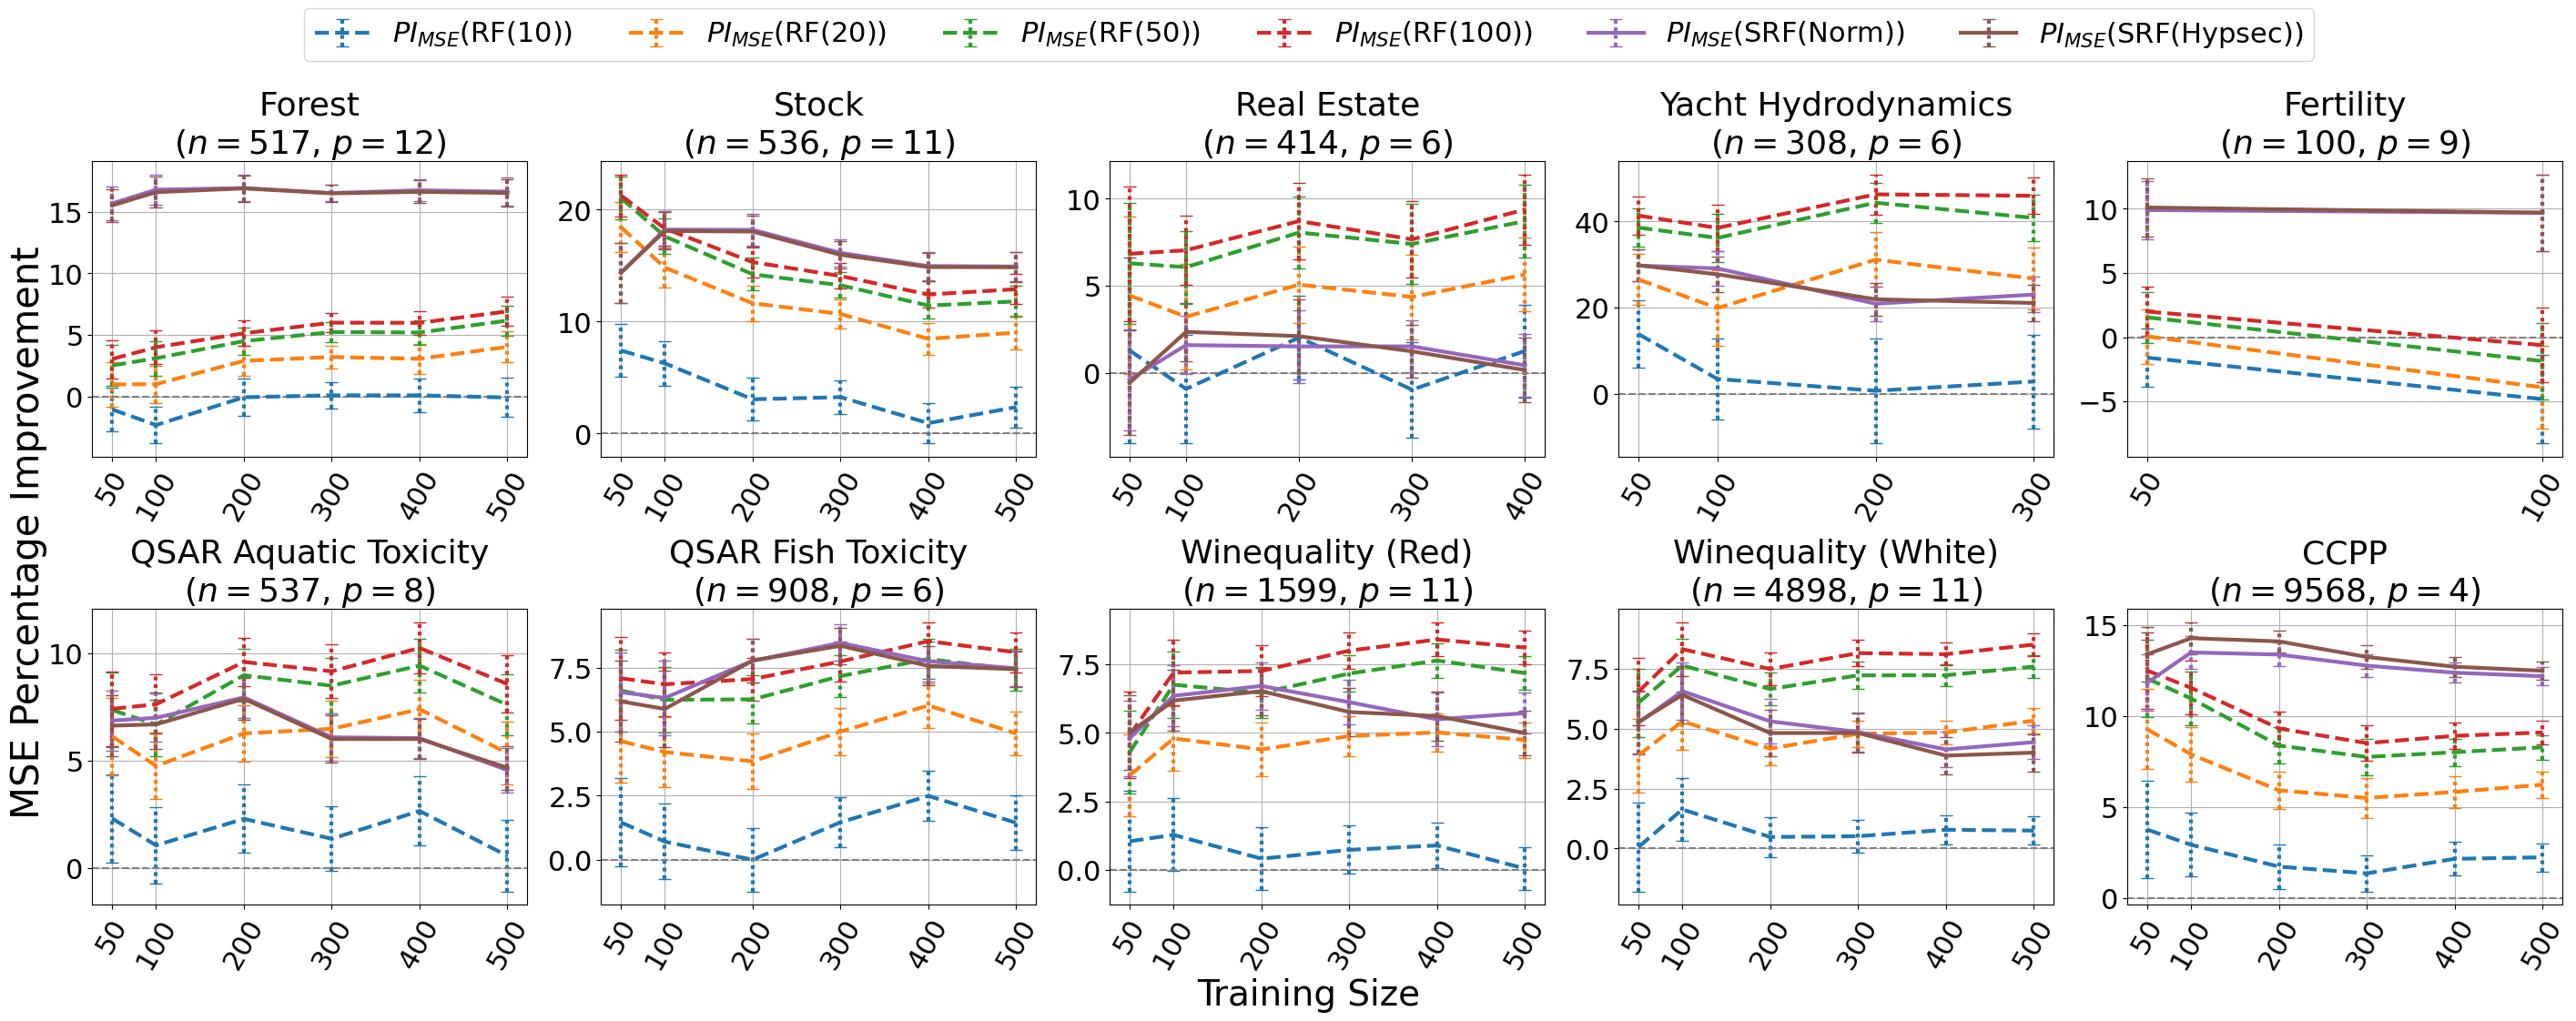

In [351]:
plot_metric_percentage_improve(result_df=best_model_pi,
                               data_name_mapping = data_name_mapping,
                               ncol=5,
                               show_legend = True,
                               figure_size = (28,10),
                               plot_type = 'errorbar',
                               save_path = './figures/best_model_pi.pdf')

In [352]:
best_model_pi

,Data,N,P,n_obs,r,rf10,rf20,rf50,rf100,SRF(norm),SRF(hyp),cases
0,fertility,100,9,50,0,-6.7998,-7.9205,-10.1073,-4.3168,12.7273,12.5468,1
1,fertility,100,9,50,1,2.6858,11.8613,14.9435,12.9300,8.5939,11.2022,1
2,fertility,100,9,50,2,-2.9650,1.6365,-1.8944,1.5112,0.5200,0.9391,1
3,fertility,100,9,50,3,-5.4073,-13.4285,-5.3860,-5.3510,2.9201,0.7728,1
4,fertility,100,9,50,4,-10.3630,-2.2720,-0.0497,0.7377,3.5897,4.4131,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5295,Combined_Cycle_Power_Plant,9568,4,500,95,-1.6276,1.6885,5.8374,6.6939,11.4609,11.8922,1
5296,Combined_Cycle_Power_Plant,9568,4,500,96,0.0523,1.5755,5.7135,6.3770,14.7707,15.5217,1
5297,Combined_Cycle_Power_Plant,9568,4,500,97,0.6168,3.3719,6.3547,7.5817,9.7420,9.9024,1
5298,Combined_Cycle_Power_Plant,9568,4,500,98,1.9047,5.1561,7.0961,7.4053,9.4192,9.0945,1


In [363]:
print(f"SRF(norm) greater than baseline: {round(len(best_model_pi[best_model_pi['SRF(norm)']>0])/len(best_model_pi),2)*100}%")
print(f"SRF(hyp) greater than baseline: {round(len(best_model_pi[best_model_pi['SRF(hyp)']>0])/len(best_model_pi),2)*100}%")

SRF(norm) greater than baseline: 89.0%
SRF(hyp) greater than baseline: 88.0%


In [364]:
print(f"SRF(norm) greater than RF10 cases {len(best_model_pi[best_model_pi['SRF(norm)']>best_model_pi['rf10']])} percentage {round(len(best_model_pi[best_model_pi['SRF(norm)']>best_model_pi['rf10']])/len(best_model_pi),2)*100}%")
print(f"SRF(hyp) greater than RF10 cases {len(best_model_pi[best_model_pi['SRF(hyp)']>best_model_pi['rf10']])} percentage {round(len(best_model_pi[best_model_pi['SRF(hyp)']>best_model_pi['rf10']])/len(best_model_pi),2)*100}%")
print(f"SRF(norm) greater than RF20 cases {len(best_model_pi[best_model_pi['SRF(norm)']>best_model_pi['rf20']])} percentage {round(len(best_model_pi[best_model_pi['SRF(norm)']>best_model_pi['rf20']])/len(best_model_pi),2)*100}%")
print(f"SRF(hyp) greater than RF20 cases {len(best_model_pi[best_model_pi['SRF(hyp)']>best_model_pi['rf20']])} percentage {round(len(best_model_pi[best_model_pi['SRF(hyp)']>best_model_pi['rf20']])/len(best_model_pi),2)*100}%")
print(f"SRF(norm) greater than RF50 cases {len(best_model_pi[best_model_pi['SRF(norm)']>best_model_pi['rf50']])} percentage {round(len(best_model_pi[best_model_pi['SRF(norm)']>best_model_pi['rf50']])/len(best_model_pi),2)*100}%")
print(f"SRF(hyp) greater than RF50 cases {len(best_model_pi[best_model_pi['SRF(hyp)']>best_model_pi['rf50']])} percentage {round(len(best_model_pi[best_model_pi['SRF(hyp)']>best_model_pi['rf50']])/len(best_model_pi),2)*100}%")
print(f"SRF(norm) greater than RF100 cases {len(best_model_pi[best_model_pi['SRF(norm)']>best_model_pi['rf100']])} percentage {round(len(best_model_pi[best_model_pi['SRF(norm)']>best_model_pi['rf100']])/len(best_model_pi),2)*100}%")
print(f"SRF(hyp) greater than RF100 cases {len(best_model_pi[best_model_pi['SRF(hyp)']>best_model_pi['rf100']])} percentage {round(len(best_model_pi[best_model_pi['SRF(hyp)']>best_model_pi['rf100']])/len(best_model_pi),2)*100}%")

SRF(norm) greater than RF10 cases 4236 percentage 80.0%
SRF(hyp) greater than RF10 cases 4244 percentage 80.0%
SRF(norm) greater than RF20 cases 3465 percentage 65.0%
SRF(hyp) greater than RF20 cases 3445 percentage 65.0%
SRF(norm) greater than RF50 cases 2810 percentage 53.0%
SRF(hyp) greater than RF50 cases 2820 percentage 53.0%
SRF(norm) greater than RF100 cases 2619 percentage 49.0%
SRF(hyp) greater than RF100 cases 2623 percentage 49.0%


# Analysis the reliability of CV 

In [365]:
cv_best_model_selection_df

,data,n,r,best_SRF_norm,best_SRF_hyp
0,fertility,50,0,per_tree_dim,per_tree_dim
1,fertility,50,1,global,per_tree_dim
2,fertility,50,2,per_tree_dim,per_tree_dim
3,fertility,50,3,per_tree_dim,per_tree_dim
4,fertility,50,4,per_tree_dim,per_tree_dim
...,...,...,...,...,...
595,Combined_Cycle_Power_Plant,500,95,per_tree,per_tree_dim
596,Combined_Cycle_Power_Plant,500,96,per_tree_dim,per_tree_dim
597,Combined_Cycle_Power_Plant,500,97,per_tree_dim,per_tree_dim
598,Combined_Cycle_Power_Plant,500,98,per_tree_dim,per_tree_dim


In [368]:
combined_mse_SRF = combined_mse[['data','n_obs','r','srf_normal_global','srf_normal_per_dim','srf_normal_per_tree','srf_normal_per_tree_dim','srf_hypsec_global','srf_hypsec_per_dim','srf_hypsec_per_tree','srf_hypsec_per_tree_dim']]

In [369]:
combined_mse_SRF

,data,n_obs,r,srf_normal_global,srf_normal_per_dim,srf_normal_per_tree,srf_normal_per_tree_dim,srf_hypsec_global,srf_hypsec_per_dim,srf_hypsec_per_tree,srf_hypsec_per_tree_dim
0,fertility,50,0,0.037906,0.038305,0.038195,0.036698,0.037796,0.038361,0.038218,0.036774
1,fertility,50,1,0.036886,0.039730,0.037839,0.034898,0.036858,0.039973,0.038715,0.035834
2,fertility,50,2,0.040955,0.042024,0.040910,0.040070,0.040893,0.042142,0.041661,0.039901
3,fertility,50,3,0.037678,0.040765,0.040368,0.036241,0.037869,0.040684,0.040569,0.037043
4,fertility,50,4,0.035516,0.035561,0.035445,0.033234,0.035472,0.035538,0.035536,0.032951
...,...,...,...,...,...,...,...,...,...,...,...
595,Combined_Cycle_Power_Plant,500,95,18.017967,18.190367,18.351168,18.282934,18.046246,18.254390,18.110081,18.261759
596,Combined_Cycle_Power_Plant,500,96,17.871158,18.080545,18.025393,18.195703,17.908697,18.073451,17.961752,18.035373
597,Combined_Cycle_Power_Plant,500,97,18.605252,18.637806,18.672389,18.617518,18.595323,18.600874,18.548112,18.584445
598,Combined_Cycle_Power_Plant,500,98,18.500106,18.574570,18.538096,18.622296,18.497077,18.558536,18.460729,18.689058


In [367]:
srf_norml_models = ['srf_normal_global','srf_normal_per_dim','srf_normal_per_tree','srf_normal_per_tree_dim']
srf_hypsec_models = ['srf_hypsec_global','srf_hypsec_per_dim','srf_hypsec_per_tree','srf_hypsec_per_tree_dim']

In [ ]:

merged_df = combined_mse_SRF.merge(
    cv_best_model_selection_df, 
    left_on=['data', 'n_obs', 'r'], 
    right_on=['data', 'n', 'r']
)


normal_cols = ['srf_normal_global', 'srf_normal_per_dim', 'srf_normal_per_tree', 'srf_normal_per_tree_dim']
hypsec_cols = ['srf_hypsec_global', 'srf_hypsec_per_dim', 'srf_hypsec_per_tree', 'srf_hypsec_per_tree_dim']

merged_df['true_best_normal'] = merged_df[normal_cols].idxmin(axis=1).str.replace('srf_normal_', '')
merged_df['true_best_hypsec'] = merged_df[hypsec_cols].idxmin(axis=1).str.replace('srf_hypsec_', '')


merged_df['normal_correct'] = merged_df['best_SRF_norm'] == merged_df['true_best_normal']
merged_df['hypsec_correct'] = merged_df['best_SRF_hyp'] == merged_df['true_best_hypsec']


normal_accuracy = merged_df['normal_correct'].mean()
hypsec_accuracy = merged_df['hypsec_correct'].mean()
overall_accuracy = merged_df[['normal_correct', 'hypsec_correct']].mean().mean()

print(f"Normal kernel CV accuracy: {normal_accuracy:.2%}")
print(f"Hyperbolic Secant kernel CV accuracy: {hypsec_accuracy:.2%}")
print(f"Overall CV accuracy: {overall_accuracy:.2%}")


accuracy_by_dataset = merged_df.groupby(['data', 'n_obs']).agg({
    'normal_correct': 'mean',
    'hypsec_correct': 'mean'
}).round(4)

Normal kernel CV accuracy: 57.13%
Hyperbolic Secant kernel CV accuracy: 56.55%
Overall CV accuracy: 56.84%


In [372]:
combined_mse

,data,n_obs,r,base_rf,rf10,rf20,rf50,rf100,srf_normal_global,srf_normal_per_dim,srf_normal_per_tree,srf_normal_per_tree_dim,srf_hypsec_global,srf_hypsec_per_dim,srf_hypsec_per_tree,srf_hypsec_per_tree_dim
0,fertility,50,0,0.042050,0.044909,0.045380,0.046300,0.043865,0.037906,0.038305,0.038195,0.036698,0.037796,0.038361,0.038218,0.036774
1,fertility,50,1,0.040354,0.039270,0.035568,0.034324,0.035136,0.036886,0.039730,0.037839,0.034898,0.036858,0.039973,0.038715,0.035834
2,fertility,50,2,0.040279,0.041473,0.039620,0.041042,0.039670,0.040955,0.042024,0.040910,0.040070,0.040893,0.042142,0.041661,0.039901
3,fertility,50,3,0.037332,0.039350,0.042345,0.039342,0.039329,0.037678,0.040765,0.040368,0.036241,0.037869,0.040684,0.040569,0.037043
4,fertility,50,4,0.034472,0.038044,0.035255,0.034489,0.034218,0.035516,0.035561,0.035445,0.033234,0.035472,0.035538,0.035536,0.032951
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,Combined_Cycle_Power_Plant,500,95,20.726619,21.063966,20.376660,19.516723,19.339205,18.017967,18.190367,18.351168,18.282934,18.046246,18.254390,18.110081,18.261759
596,Combined_Cycle_Power_Plant,500,96,21.349108,21.337937,21.012749,20.129322,19.987684,17.871158,18.080545,18.025393,18.195703,17.908697,18.073451,17.961752,18.035373
597,Combined_Cycle_Power_Plant,500,97,20.627010,20.499778,19.931488,19.316219,19.063135,18.605252,18.637806,18.672389,18.617518,18.595323,18.600874,18.548112,18.584445
598,Combined_Cycle_Power_Plant,500,98,20.558776,20.167187,19.498746,19.099909,19.036338,18.500106,18.574570,18.538096,18.622296,18.497077,18.558536,18.460729,18.689058


In [377]:
all_models_pi.groupby(['data']).mean().reset_index().drop(columns=['n_obs','r'])[['data','rf10','rf20','rf50','rf100','srf_normal_per_tree_dim','srf_hypsec_per_tree_dim']]

,data,rf10,rf20,rf50,rf100,srf_normal_per_tree_dim,srf_hypsec_per_tree_dim
0,Combined_Cycle_Power_Plant,2.369296,6.783136,9.251076,9.990132,12.758073,13.292307
1,fertility,-3.200528,-1.914922,-0.154162,0.691036,11.030173,11.227893
2,forest,-0.533817,2.542883,4.462138,5.186017,16.140594,15.978667
3,qsar_aquatic_toxicity,1.714275,6.072651,8.096803,8.776720,6.501507,6.367068
4,qsar_fish_toxicity,1.257037,4.773420,6.927701,7.567488,7.623683,7.562947
5,real_estate,0.544440,4.553913,7.311933,7.931318,2.056910,2.238344
6,stock,3.875635,12.174343,14.896424,15.714787,16.268269,16.160328
7,winequality-red,0.737549,4.545769,6.578623,7.311013,6.963565,6.972634
8,winequality-white,0.699309,4.716045,7.064115,7.847116,6.550188,6.542252
9,yacht_hydrodynamics,5.242822,26.086825,39.982941,43.025708,27.619270,27.314631


In [392]:
cv_best_model_selection_df[['best_SRF_norm']].value_counts()/len(cv_best_model_selection_df)

best_SRF_norm
per_tree_dim     0.740755
global           0.168113
per_tree         0.046038
per_dim          0.045094
Name: count, dtype: float64

In [393]:
cv_best_model_selection_df[['best_SRF_hyp']].value_counts()/len(cv_best_model_selection_df)

best_SRF_hyp
per_tree_dim    0.731132
global          0.188302
per_dim         0.042264
per_tree        0.038302
Name: count, dtype: float64

In [394]:
combined_mse[normal_cols].idxmin(axis=1).value_counts()/len(combined_mse)

srf_normal_per_tree_dim    0.658302
srf_normal_global          0.204340
srf_normal_per_dim         0.080189
srf_normal_per_tree        0.057170
Name: count, dtype: float64

In [395]:
combined_mse[hypsec_cols].idxmin(axis=1).value_counts()/len(combined_mse)

srf_hypsec_per_tree_dim    0.660000
srf_hypsec_global          0.185660
srf_hypsec_per_dim         0.090189
srf_hypsec_per_tree        0.064151
Name: count, dtype: float64

# 95% CI Coverage Rate

    



In [199]:
from scipy.stats import norm

In [200]:
def get_CI(y_pred, std, alpha=0.05):
    z = norm.ppf(1-alpha/2)
    CI = z*std
    return y_pred - CI, y_pred + CI

def get_CI_coverage(y_pred,y_true,y_std,alpha = 0.05):
    ci_low, ci_high = get_CI(y_pred,y_std,alpha)
    ci_cover_no = np.logical_and(ci_low<y_true,ci_high>y_true).astype(int).sum()
    return ci_cover_no/y_true.shape[0]

In [205]:
def calculate_CI_CR(data_name, n_obs_list_full = [50,100,200,300,400,500], 
                            results_dir='../results', metrics_dir='./metrics'):
    """
    Calculate MSE for all models across different sample sizes and replications
    
    Args:
        data_name: Dataset name (e.g., 'autompg')
        n_obs_list: List of sample sizes to analyze
        save: Whether to save results to CSV
        results_dir: Directory containing experiment results
        metrics_dir: Directory to save metrics (if None, won't save even if save=True)
    
    Returns:
        DataFrame with columns: data, n_obs, r, base_rf, rf10, rf100, srf_normal_*, srf_hypsec_*
    """
    n_obs_list = get_valid_n_obs_list(data_name, n_obs_list_full)
    # List to store results
    results_list = []
    
    # Define all model names (use original names for reading)
    rf_names = ['base_rf', 'rf10', 'rf20', 'rf50','rf_100']


    model_names = []
    # Add SRF models (2 kernels × 4 modes)
    for kernel in ['normal', 'hypsec']:
        for mode in ['global', 'per_dim', 'per_tree', 'per_tree_dim']:
            model_names.append(f'srf_{kernel}_{mode}')
    
    # Iterate through all sample sizes and replications
    for n_obs in n_obs_list:
        for r in range(100):  # 100 replications
            pred_file = f'{results_dir}/{data_name}/predictions/{data_name}_n{n_obs}_r{r}.csv'
            
            # Check if file exists
            if not os.path.exists(pred_file):
                continue
            
            try:
                # Load predictions
                pred_df = pd.read_csv(pred_file)
                y_test = pred_df['y_test'].values
                
                # Create result dictionary for this replication
                result = {
                    'data': data_name,
                    'n_obs': n_obs,
                    'r': r
                }

                for rf_name in rf_names:
                    rf_pred = pred_df[f'{rf_name}_pred']
                    rf_std = pred_df[f'{rf_name}_std']

                    result[f'{rf_name}'] = get_CI_coverage(y_pred=rf_pred,
                                                    y_true=y_test,
                                                    y_std=rf_std)
                
                # Calculate MSE for each model
                for model in model_names:
                    pred_col = f'{model}_pred'
                    pred_std = f'{model}_total_std'
                    pred_noise_free_std = f'{model}_noise_free_std'
                    
                    result[f'{model}_noise_free'] = get_CI_coverage(y_pred=pred_df[pred_col],
                                                    y_true=y_test,
                                                    y_std=pred_df[pred_noise_free_std])
                    result[f'{model}'] = get_CI_coverage(y_pred=pred_df[pred_col],
                                                    y_true=y_test,
                                                    y_std=pred_df[pred_std])
                
                results_list.append(result)
                
            except Exception as e:
                print(f"Error processing {data_name} n={n_obs} r={r}: {e}")
                continue
    
    # Create DataFrame
    results_df = pd.DataFrame(results_list)
    
    # Rename rf_full to rf100
    # model_names_display = [m if m != 'rf_full' else 'rf100' for m in model_names]
    results_df.rename(columns={'rf_full': 'rf100'}, inplace=True)
    
    cols_order = ['data', 'n_obs', 'r'] + ['base_rf', 'rf10', 'rf20', 'rf50','rf_100']
    for model in model_names:
        cols_order.append(f'{model}_noise_free')
        cols_order.append(model)
    results_df = results_df[cols_order]
    
    # Save if requested and metrics_dir is not None
    if metrics_dir is not None:
        save_path = f'{metrics_dir}/{data_name}/{data_name}_CI_coverage.csv'
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        results_df.to_csv(save_path, index=False)
        print(f"Saved metrics to: {save_path}")
    
    else:
        return results_df

In [206]:
for data in data_names:
    calculate_CI_CR(data_name=data,metrics_dir= './metrics')

Saved metrics to: ./metrics/fertility/fertility_CI_coverage.csv
Saved metrics to: ./metrics/forest/forest_CI_coverage.csv
Saved metrics to: ./metrics/qsar_aquatic_toxicity/qsar_aquatic_toxicity_CI_coverage.csv
Saved metrics to: ./metrics/stock/stock_CI_coverage.csv
Saved metrics to: ./metrics/yacht_hydrodynamics/yacht_hydrodynamics_CI_coverage.csv
Saved metrics to: ./metrics/real_estate/real_estate_CI_coverage.csv
Saved metrics to: ./metrics/winequality-red/winequality-red_CI_coverage.csv
Saved metrics to: ./metrics/winequality-white/winequality-white_CI_coverage.csv
Saved metrics to: ./metrics/qsar_fish_toxicity/qsar_fish_toxicity_CI_coverage.csv
Saved metrics to: ./metrics/Combined_Cycle_Power_Plant/Combined_Cycle_Power_Plant_CI_coverage.csv


In [207]:
models_CI_coverage = combine_all_data_metrics(metric='CI_coverage',
                                                        data_list=data_names,
                                                        metrics_path= './metrics')

In [208]:
models_CI_coverage

,data,n_obs,r,base_rf,rf10,rf20,rf50,rf_100,srf_normal_global_noise_free,srf_normal_global,...,srf_normal_per_tree_dim_noise_free,srf_normal_per_tree_dim,srf_hypsec_global_noise_free,srf_hypsec_global,srf_hypsec_per_dim_noise_free,srf_hypsec_per_dim,srf_hypsec_per_tree_noise_free,srf_hypsec_per_tree,srf_hypsec_per_tree_dim_noise_free,srf_hypsec_per_tree_dim
0,fertility,50,0,0.776119,0.686567,0.716418,0.731343,0.761194,0.477612,0.925373,...,0.850746,0.925373,0.492537,0.925373,0.208955,0.925373,0.492537,0.955224,0.850746,0.925373
1,fertility,50,1,0.701493,0.820896,0.791045,0.835821,0.865672,0.686567,0.835821,...,0.895522,0.940299,0.686567,0.835821,0.208955,0.910448,0.477612,0.910448,0.880597,0.925373
2,fertility,50,2,0.776119,0.820896,0.850746,0.820896,0.835821,0.313433,0.940299,...,0.985075,1.000000,0.313433,0.940299,0.194030,0.940299,0.343284,0.940299,1.000000,1.000000
3,fertility,50,3,0.731343,0.791045,0.776119,0.791045,0.776119,0.537313,0.850746,...,0.835821,0.895522,0.507463,0.850746,0.716418,0.895522,0.343284,0.895522,0.850746,0.910448
4,fertility,50,4,0.791045,0.522388,0.656716,0.791045,0.791045,0.358209,0.940299,...,0.955224,1.000000,0.388060,0.940299,0.074627,0.940299,0.388060,0.940299,0.955224,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,Combined_Cycle_Power_Plant,500,95,0.812757,0.848603,0.875785,0.898419,0.911306,0.982023,0.994260,...,0.978666,0.992961,0.983647,0.994152,0.978774,0.993069,0.985164,0.995127,0.984081,0.994694
596,Combined_Cycle_Power_Plant,500,96,0.846329,0.819796,0.869396,0.891921,0.903509,0.983431,0.993177,...,0.978991,0.990253,0.985055,0.993286,0.982564,0.992203,0.984947,0.993286,0.986138,0.993177
597,Combined_Cycle_Power_Plant,500,97,0.853909,0.843297,0.885207,0.904700,0.911414,0.977041,0.991986,...,0.978882,0.990687,0.980182,0.992528,0.979532,0.991878,0.981048,0.992744,0.983214,0.991986
598,Combined_Cycle_Power_Plant,500,98,0.837015,0.849794,0.882391,0.897986,0.904483,0.977908,0.991661,...,0.978666,0.990037,0.979749,0.991878,0.978016,0.991120,0.978558,0.991553,0.979099,0.990578


In [209]:
models_CI_coverage.groupby(['data']).mean().reset_index().drop(columns=['n_obs','r'])

,data,base_rf,rf10,rf20,rf50,rf_100,srf_normal_global_noise_free,srf_normal_global,srf_normal_per_dim_noise_free,srf_normal_per_dim,...,srf_normal_per_tree_dim_noise_free,srf_normal_per_tree_dim,srf_hypsec_global_noise_free,srf_hypsec_global,srf_hypsec_per_dim_noise_free,srf_hypsec_per_dim,srf_hypsec_per_tree_noise_free,srf_hypsec_per_tree,srf_hypsec_per_tree_dim_noise_free,srf_hypsec_per_tree_dim
0,Combined_Cycle_Power_Plant,0.830216,0.828524,0.868292,0.890636,0.898932,0.972311,0.988984,0.966377,0.986387,...,0.973287,0.987377,0.975871,0.989901,0.974720,0.989533,0.971511,0.988053,0.980866,0.990865
1,fertility,0.756967,0.751156,0.783815,0.804692,0.812976,0.642788,0.924740,0.523487,0.948191,...,0.925005,0.962829,0.639898,0.921038,0.474701,0.946536,0.696074,0.956689,0.927479,0.963351
2,forest,0.831775,0.837941,0.869572,0.885429,0.891607,0.454609,0.932303,0.405815,0.925570,...,0.784496,0.931648,0.480546,0.932571,0.460669,0.930548,0.549895,0.930960,0.816657,0.936592
3,qsar_aquatic_toxicity,0.826776,0.828256,0.867677,0.889826,0.896663,0.911376,0.968769,0.959986,0.986790,...,0.965627,0.982649,0.915653,0.969018,0.968672,0.990372,0.969545,0.988909,0.968202,0.983726
4,qsar_fish_toxicity,0.813831,0.810803,0.849818,0.872928,0.881013,0.920151,0.967025,0.976527,0.990905,...,0.967640,0.982067,0.923701,0.967801,0.982292,0.993558,0.981095,0.991761,0.969584,0.982822
5,real_estate,0.799800,0.789519,0.836308,0.866013,0.876392,0.824097,0.941489,0.909407,0.974751,...,0.933724,0.966475,0.836593,0.946063,0.911188,0.975736,0.899361,0.975423,0.939850,0.968409
6,stock,0.861658,0.861302,0.889007,0.910799,0.919773,0.598200,0.948165,0.598208,0.948412,...,0.990363,0.992833,0.536397,0.943635,0.536397,0.943635,0.764602,0.964373,0.991103,0.993377
7,winequality-red,0.819924,0.816162,0.870057,0.894000,0.900510,0.835869,0.953186,0.858084,0.977140,...,0.967293,0.985886,0.833807,0.950494,0.846531,0.977326,0.899148,0.980961,0.969431,0.986875
8,winequality-white,0.824616,0.824748,0.873730,0.896297,0.903756,0.719389,0.935858,0.715951,0.958581,...,0.948260,0.981105,0.720810,0.934032,0.704211,0.959154,0.777783,0.964429,0.952780,0.982691
9,yacht_hydrodynamics,0.959314,0.957951,0.981175,0.989994,0.992860,0.984618,0.994637,0.996154,0.996931,...,0.996999,0.997365,0.985745,0.994895,0.996717,0.997070,0.997800,0.998087,0.997184,0.997440


In [212]:
# create dataframe for CI coverage with noise
model_names = ['data','n_obs','r','base_rf', 'rf10', 'rf20', 'rf50','rf_100']
model_name_noise_free = ['data','n_obs','r','base_rf', 'rf10', 'rf20', 'rf50','rf_100']
for kernel in ['normal', 'hypsec']:
        for mode in ['global', 'per_dim', 'per_tree', 'per_tree_dim']:
            model_names.append(f'srf_{kernel}_{mode}')
            model_name_noise_free.append(f'srf_{kernel}_{mode}_noise_free')

In [213]:
models_ci_coverage_noise = models_CI_coverage[model_names]

In [214]:
models_ci_coverage_noise.groupby(['data']).mean().reset_index().drop(columns=['n_obs','r'])

,data,base_rf,rf10,rf20,rf50,rf_100,srf_normal_global,srf_normal_per_dim,srf_normal_per_tree,srf_normal_per_tree_dim,srf_hypsec_global,srf_hypsec_per_dim,srf_hypsec_per_tree,srf_hypsec_per_tree_dim
0,Combined_Cycle_Power_Plant,0.830216,0.828524,0.868292,0.890636,0.898932,0.988984,0.986387,0.980202,0.987377,0.989901,0.989533,0.988053,0.990865
1,fertility,0.756967,0.751156,0.783815,0.804692,0.812976,0.924740,0.948191,0.957365,0.962829,0.921038,0.946536,0.956689,0.963351
2,forest,0.831775,0.837941,0.869572,0.885429,0.891607,0.932303,0.925570,0.926990,0.931648,0.932571,0.930548,0.930960,0.936592
3,qsar_aquatic_toxicity,0.826776,0.828256,0.867677,0.889826,0.896663,0.968769,0.986790,0.984549,0.982649,0.969018,0.990372,0.988909,0.983726
4,qsar_fish_toxicity,0.813831,0.810803,0.849818,0.872928,0.881013,0.967025,0.990905,0.987446,0.982067,0.967801,0.993558,0.991761,0.982822
5,real_estate,0.799800,0.789519,0.836308,0.866013,0.876392,0.941489,0.974751,0.974576,0.966475,0.946063,0.975736,0.975423,0.968409
6,stock,0.861658,0.861302,0.889007,0.910799,0.919773,0.948165,0.948412,0.970757,0.992833,0.943635,0.943635,0.964373,0.993377
7,winequality-red,0.819924,0.816162,0.870057,0.894000,0.900510,0.953186,0.977140,0.980387,0.985886,0.950494,0.977326,0.980961,0.986875
8,winequality-white,0.824616,0.824748,0.873730,0.896297,0.903756,0.935858,0.958581,0.964112,0.981105,0.934032,0.959154,0.964429,0.982691
9,yacht_hydrodynamics,0.959314,0.957951,0.981175,0.989994,0.992860,0.994637,0.996931,0.997578,0.997365,0.994895,0.997070,0.998087,0.997440


In [215]:
models_ci_coverage_noise_free = models_CI_coverage[model_name_noise_free]

In [216]:
models_ci_coverage_noise_free.groupby(['data']).mean().reset_index().drop(columns=['n_obs','r'])

,data,base_rf,rf10,rf20,rf50,rf_100,srf_normal_global_noise_free,srf_normal_per_dim_noise_free,srf_normal_per_tree_noise_free,srf_normal_per_tree_dim_noise_free,srf_hypsec_global_noise_free,srf_hypsec_per_dim_noise_free,srf_hypsec_per_tree_noise_free,srf_hypsec_per_tree_dim_noise_free
0,Combined_Cycle_Power_Plant,0.830216,0.828524,0.868292,0.890636,0.898932,0.972311,0.966377,0.951822,0.973287,0.975871,0.974720,0.971511,0.980866
1,fertility,0.756967,0.751156,0.783815,0.804692,0.812976,0.642788,0.523487,0.733838,0.925005,0.639898,0.474701,0.696074,0.927479
2,forest,0.831775,0.837941,0.869572,0.885429,0.891607,0.454609,0.405815,0.494482,0.784496,0.480546,0.460669,0.549895,0.816657
3,qsar_aquatic_toxicity,0.826776,0.828256,0.867677,0.889826,0.896663,0.911376,0.959986,0.958281,0.965627,0.915653,0.968672,0.969545,0.968202
4,qsar_fish_toxicity,0.813831,0.810803,0.849818,0.872928,0.881013,0.920151,0.976527,0.972430,0.967640,0.923701,0.982292,0.981095,0.969584
5,real_estate,0.799800,0.789519,0.836308,0.866013,0.876392,0.824097,0.909407,0.895001,0.933724,0.836593,0.911188,0.899361,0.939850
6,stock,0.861658,0.861302,0.889007,0.910799,0.919773,0.598200,0.598208,0.816144,0.990363,0.536397,0.536397,0.764602,0.991103
7,winequality-red,0.819924,0.816162,0.870057,0.894000,0.900510,0.835869,0.858084,0.904773,0.967293,0.833807,0.846531,0.899148,0.969431
8,winequality-white,0.824616,0.824748,0.873730,0.896297,0.903756,0.719389,0.715951,0.783936,0.948260,0.720810,0.704211,0.777783,0.952780
9,yacht_hydrodynamics,0.959314,0.957951,0.981175,0.989994,0.992860,0.984618,0.996154,0.953523,0.996999,0.985745,0.996717,0.997800,0.997184


# Get CV selected model's CI coverage

In [220]:
def create_selected_models_CI_coverage_df(combined_CI_coverage_df, cv_best_model_df):
    """
    Create a DataFrame with MSE values for selected best models
    
    Args:
        combined_mse_df: DataFrame with all models' MSE (from calculate_mse_metrics)
        cv_best_model_df: DataFrame with best model selection (from create_best_model_selection_df)
    
    Returns:
        DataFrame with columns: data, n, r, base_rf, rf10, rf10_opt, rf100, SRF(norm), SRF(hyp)
    """
    import pandas as pd
    import numpy as np
    
    # Merge the two dataframes on data, n_obs/n, and r
    # First, standardize column names
    ci_CR_df = combined_CI_coverage_df.copy()
    best_df = cv_best_model_df.copy()
    
    # Rename 'n' to 'n_obs' in best_df if needed for merging
    if 'n' in best_df.columns:
        best_df = best_df.rename(columns={'n': 'n_obs'})
    
    # Merge on data, n_obs, r
    merged_df = pd.merge(ci_CR_df, best_df, on=['data', 'n_obs', 'r'], how='inner')
    
    # Create result list
    results_list = []
    
    for idx, row in merged_df.iterrows():
        # Get basic info
        data_name = row['data']
        n_obs = row['n_obs']
        r = row['r']
        
        # Get baseline models MSE
        base_rf_mse = row['base_rf']
        rf10_mse = row['rf10']
        rf20_mse = row['rf20']
        rf50_mse = row['rf50']
        rf100_mse = row['rf_100']
        
        # Get best model modes
        best_norm_mode = row['best_SRF_norm']
        best_hyp_mode = row['best_SRF_hyp']
        
        # Get corresponding SRF MSE values
        srf_norm_col = f'srf_normal_{best_norm_mode}'
        srf_hyp_col = f'srf_hypsec_{best_hyp_mode}'
        
        srf_norm_mse = row[srf_norm_col] if srf_norm_col in row else np.nan
        srf_hyp_mse = row[srf_hyp_col] if srf_hyp_col in row else np.nan
        
        # Create result dictionary
        result = {
            'data': data_name,
            'n': n_obs,
            'r': r,
            'base_rf': base_rf_mse,
            'rf10': rf10_mse,
            'rf20': rf20_mse,
            'rf50': rf50_mse,
            'rf100': rf100_mse,
            'SRF(norm)': srf_norm_mse,
            'SRF(hyp)': srf_hyp_mse
        }
        
        results_list.append(result)
    
    # Create final DataFrame
    result_df = pd.DataFrame(results_list)
    
    return result_df

In [221]:
cv_selected_models_CI_coverage = create_selected_models_CI_coverage_df(combined_CI_coverage_df = models_CI_coverage, 
                                                                         cv_best_model_df = cv_best_model_selection_df)


In [224]:
cv_selected_models_CI_coverage.groupby(['data','n']).mean().reset_index().drop(columns=['r'])

,data,n,base_rf,rf10,rf20,rf50,rf100,SRF(norm),SRF(hyp)
0,Combined_Cycle_Power_Plant,50,0.824048,0.820468,0.855736,0.878787,0.884884,0.972227,0.980281
1,Combined_Cycle_Power_Plant,100,0.816507,0.814825,0.858710,0.883356,0.893658,0.984120,0.989501
2,Combined_Cycle_Power_Plant,200,0.827626,0.826367,0.867042,0.889728,0.898403,0.988758,0.991854
3,Combined_Cycle_Power_Plant,300,0.833978,0.834617,0.874320,0.895897,0.904521,0.989921,0.992426
4,Combined_Cycle_Power_Plant,400,0.835296,0.832048,0.872951,0.894537,0.903202,0.990027,0.992481
5,Combined_Cycle_Power_Plant,500,0.843843,0.842817,0.880994,0.901515,0.908927,0.990438,0.992316
6,fertility,50,0.760299,0.747463,0.776418,0.800597,0.807164,0.948507,0.946716
7,fertility,100,0.753636,0.754848,0.791212,0.808788,0.818788,0.955758,0.949394
8,forest,50,0.800041,0.797769,0.831467,0.847975,0.854917,0.906198,0.910620
9,forest,100,0.813489,0.824756,0.860689,0.878889,0.885422,0.923756,0.929378
